In [268]:
import numpy as np
import pandas as pd
import math
import warnings

warnings.filterwarnings("ignore")

# PART B

### Task B1

In [269]:

df =pd.read_csv("/content/diabetic_data.csv")
# first few records
df = df.sample(n=10000, random_state=42).reset_index(drop=True)
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,90827382,2975652,Caucasian,Male,[70-80),?,1,1,6,3,...,No,No,No,No,No,No,No,Ch,Yes,>30
1,110650854,23195790,Caucasian,Male,[80-90),?,3,1,1,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
2,37648860,3521574,Caucasian,Male,[60-70),?,2,1,1,6,...,No,No,No,No,No,No,No,No,Yes,NO
3,153502992,45604485,Caucasian,Female,[30-40),?,1,2,7,2,...,No,No,No,No,No,No,No,No,No,>30
4,63820230,3931137,Caucasian,Male,[80-90),?,2,18,1,2,...,No,No,No,No,No,No,No,No,Yes,>30


In [270]:
# from google.colab import drive
# drive.mount('/content/drive')

In [271]:
# last few records
df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
9995,164185218,43204842,Caucasian,Female,[50-60),?,3,1,1,5,...,No,Up,No,No,No,No,No,Ch,Yes,>30
9996,148976598,57700872,Caucasian,Male,[40-50),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,>30
9997,66792342,2523375,Caucasian,Female,[80-90),?,1,18,7,7,...,No,No,No,No,No,No,No,No,No,NO
9998,143148450,111141936,Caucasian,Female,[60-70),?,3,1,1,3,...,No,No,No,No,No,No,No,Ch,Yes,>30
9999,142937820,40780521,Caucasian,Male,[80-90),?,1,1,7,2,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [272]:
# shape
print("shape :",df.shape)
print("no of records :",df.shape[0])
print("no of features :",df.shape[1])

shape : (10000, 50)
no of records : 10000
no of features : 50


In [273]:
# gives the data type of features
# df.info()
count =0
for col in df.columns:
    print(count,"  ",col,"  ",type(df[col][0]).__name__,"\n")
    count+=1

0    encounter_id    int64 

1    patient_nbr    int64 

2    race    str 

3    gender    str 

4    age    str 

5    weight    str 

6    admission_type_id    int64 

7    discharge_disposition_id    int64 

8    admission_source_id    int64 

9    time_in_hospital    int64 

10    payer_code    str 

11    medical_specialty    str 

12    num_lab_procedures    int64 

13    num_procedures    int64 

14    num_medications    int64 

15    number_outpatient    int64 

16    number_emergency    int64 

17    number_inpatient    int64 

18    diag_1    str 

19    diag_2    str 

20    diag_3    str 

21    number_diagnoses    int64 

22    max_glu_serum    float 

23    A1Cresult    float 

24    metformin    str 

25    repaglinide    str 

26    nateglinide    str 

27    chlorpropamide    str 

28    glimepiride    str 

29    acetohexamide    str 

30    glipizide    str 

31    glyburide    str 

32    tolbutamide    str 

33    pioglitazone    str 

34    rosiglitazone    str 



In [274]:
# no of unique values
df.nunique()

uniques =[]
for col in df.columns:
    uniques.append(len(df[col].unique()))
data ={
    "column":df.columns,
    "unique_values":uniques
}
Nunique =pd.DataFrame(data)
Nunique


,column,unique_values
0,encounter_id,10000
1,patient_nbr,9340
2,race,6
3,gender,2
4,age,10
5,weight,9
6,admission_type_id,7
7,discharge_disposition_id,23
8,admission_source_id,11
9,time_in_hospital,14


In [275]:
# columns with null values
df.isnull().sum()


,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


# PART J Train_test_split

In [276]:
# Calulating the no of rows in the trainign and testing
train_rows =round(80*df.shape[0]/100)
test_rows =df.shape[0]-train_rows
print("training Rows ",train_rows,"testing rows ",test_rows)
 # train-test_split
train =df.sample(train_rows,random_state=42)
test = df.drop(train.index)
# spliting the features and target of training data
y_train =train["readmitted"]
x_train =train.drop(columns="readmitted",axis =1)
# spliting the features and target of texting data
y_test =test["readmitted"]
x_test =test.drop(columns="readmitted",axis =1)
print("x_train " ,x_train.shape)
print("y_train " ,y_train.shape)
print("x_test " ,x_test.shape)
print("y_test " ,y_test.shape)

training Rows  8000 testing rows  2000
x_train  (8000, 49)
y_train  (8000,)
x_test  (2000, 49)
y_test  (2000,)


In [277]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000
mean,1.043127e+08,4.442410e+07,2.169900,4.048700,5.927100,4.538900,42.696600,1.346700,15.667300,0.301100,0.152200,0.62250,7.13630
std,5.057283e+07,3.593628e+07,1.568018,5.735923,4.497356,3.063532,19.363875,1.678625,8.213888,1.149422,0.726284,1.24304,2.00098
min,3.258480e+05,1.152000e+03,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.00000,1.00000
25%,6.211647e+07,1.299441e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.00000,5.00000
50%,1.065435e+08,3.014716e+07,2.000000,1.000000,7.000000,4.000000,44.000000,1.000000,14.000000,0.000000,0.000000,0.00000,8.00000
75%,1.506784e+08,8.043021e+07,3.000000,5.000000,7.000000,6.000000,56.000000,2.000000,20.000000,0.000000,0.000000,1.00000,9.00000
max,1.865185e+08,1.151968e+08,8.000000,28.000000,20.000000,14.000000,114.000000,6.000000,75.000000,35.000000,28.000000,19.00000,9.00000


### Task b2

In [278]:
numerical_features =df.select_dtypes(include ="number").columns
numerical_features,len(numerical_features)

(Index(['encounter_id', 'patient_nbr', 'admission_type_id',
        'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
        'num_lab_procedures', 'num_procedures', 'num_medications',
        'number_outpatient', 'number_emergency', 'number_inpatient',
        'number_diagnoses'],
       dtype='object'),
 13)

In [279]:
# mean
print("calculation",numerical_features)
x_train_mean =[]
for col in numerical_features:
    sum_ =0
    count_ =0
    for m in x_train[col]:
        count_+=1
        sum_=sum_+m
    mean_ =sum_/count_
    x_train_mean.append(mean_)
print("mean",x_train_mean)

# minimum and maximum
x_train_min =[]
x_train_max =[]
for col in numerical_features:
    max_ =0
    min_= 1000000009
    for m in x_train[col]:
        if m>max_:max_ =m
        if m<min_:min_ =m
    x_train_min.append(min_)
    x_train_max.append(max_)
print("minimum" ,x_train_min)
print("maximum", x_train_max)

# mode
x_train_mode =[]
for col in numerical_features:
    mode_ =x_train[col].mode()[0]
    x_train_mode.append(mode_)
print("mode",x_train_mode)

x_train_median = []

for col in numerical_features:
    x_sort = x_train[col].sort_values().reset_index(drop=True)
    n = len(x_sort)

    if n % 2 == 0:
        median_ = (x_sort.iloc[n // 2 - 1] + x_sort.iloc[n // 2]) / 2
    else:
        median_ = x_sort.iloc[n // 2]

    x_train_median.append(median_)

print("median", x_train_median)

# Standard_deviation and variance
x_train_std =[]
x_train_var =[]
cc =0
for col in numerical_features:
    val =0
    for i in x_train[col]:
        val+=(i-x_train_mean[cc])**2
    var =val/(x_train.shape[0]-1)
    val =math.sqrt(val/x_train.shape[0])
    x_train_std.append(val)
    cc+=1
    x_train_var.append(var)
print("standard_deviation",x_train_std)
print("variance",x_train_var)

# making a dataframe
stat_df =pd.DataFrame({
    "features":numerical_features,
    "mean":x_train_mean,
    "median":x_train_median,
    "mode":x_train_mode,
    "standard_deviation":x_train_std,
    "variance":x_train_var,
    "minimum":x_train_min,
    "maximum":x_train_max
})

calculation Index(['encounter_id', 'patient_nbr', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses'],
      dtype='object')
mean [104406042.1785, 44459220.276, 2.154125, 4.0155, 5.874375, 4.511625, 42.570625, 1.341625, 15.594125, 0.2955, 0.15625, 0.615875, 7.13225]
minimum [325848, 1152, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1]
maximum [186509028, 115184448, 8, 28, 20, 14, 114, 6, 75, 35, 22, 19, 9]
mode [np.int64(325848), np.int64(1660293), np.int64(1), np.int64(1), np.int64(7), np.int64(3), np.int64(43), np.int64(0), np.int64(12), np.int64(0), np.int64(0), np.int64(0), np.int64(9)]
median [np.float64(106712421.0), np.float64(30075669.0), np.float64(2.0), np.float64(1.0), np.float64(7.0), np.float64(4.0), np.float64(44.0), np.float64(1.0), np.float64(14.0), np.float64(0.0), np.float64(0.

In [280]:
stat_df

,features,mean,median,mode,standard_deviation,variance,minimum,maximum
0,encounter_id,1.044060e+08,106712421.0,325848,5.045726e+07,2.546254e+15,325848,186509028
1,patient_nbr,4.445922e+07,30075669.0,1660293,3.606102e+07,1.300559e+15,1152,115184448
2,admission_type_id,2.154125e+00,2.0,1,1.555674e+00,2.420423e+00,1,8
3,discharge_disposition_id,4.015500e+00,1.0,1,5.701229e+00,3.250807e+01,1,28
4,admission_source_id,5.874375e+00,7.0,7,4.451864e+00,1.982157e+01,1,20
5,time_in_hospital,4.511625e+00,4.0,3,3.046944e+00,9.285025e+00,1,14
6,num_lab_procedures,4.257062e+01,44.0,43,1.926719e+01,3.712712e+02,1,114
7,num_procedures,1.341625e+00,1.0,0,1.682979e+00,2.832771e+00,0,6
8,num_medications,1.559413e+01,14.0,12,8.147953e+00,6.639744e+01,1,75
9,number_outpatient,2.955000e-01,0.0,0,1.135861e+00,1.290341e+00,0,35


In [281]:
x_train.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,8.000000e+03,8.000000e+03,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,1.044060e+08,4.445922e+07,2.154125,4.015500,5.874375,4.511625,42.570625,1.341625,15.594125,0.295500,0.156250,0.615875,7.132250
std,5.046042e+07,3.606327e+07,1.555771,5.701585,4.452142,3.047134,19.268398,1.683084,8.148462,1.135932,0.697601,1.230655,2.001002
min,3.258480e+05,1.152000e+03,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,6.260203e+07,1.250983e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,5.000000
50%,1.067124e+08,3.007567e+07,2.000000,1.000000,7.000000,4.000000,44.000000,1.000000,14.000000,0.000000,0.000000,0.000000,8.000000
75%,1.508050e+08,8.086318e+07,3.000000,5.000000,7.000000,6.000000,56.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,1.865090e+08,1.151844e+08,8.000000,28.000000,20.000000,14.000000,114.000000,6.000000,75.000000,35.000000,22.000000,19.000000,9.000000


# PART D  (Duplicate and invalid data)

### Task D1

In [282]:
# reseting the random index to sequential
x_train =x_train.reset_index(drop =True)

In [283]:
# finding duplicate records
x_train_dup = x_train.iloc[:, 2:]
x_duplicated = []
seen = set()
for i in range(len(x_train_dup)):
    row = tuple(x_train_dup.iloc[i])
    if row in seen:
        x_duplicated.append(i)
    else:
        seen.add(row)
print("no of duplicate rows :",len(x_duplicated))
    # no duplicate records find

no of duplicate rows : 0


### Task D2

In [284]:
# there is ? in multiple rows representing the null value
print("columns","count","percentage")
null_cols =[]
for col in x_train.columns:
    c =x_train[x_train[col]=="?"]
    if len(c)>0 :
        null_cols.append(col)
        p =len(c)*100/x_train.shape[0]
        print(col,"  ",len(c),"  ",p)

columns count percentage
race    162    2.025
weight    7704    96.3
payer_code    4378    54.725
medical_specialty    3265    40.8125
diag_1    1    0.0125
diag_2    40    0.5
diag_3    115    1.4375


In [285]:
# replaceing all '?' with the nan valule

# for col in null_cols:
#     for i in x_train.index:
#         if x_train[col][i]=="?":
#             x_train.loc[i,col] =np.nan
x_train =x_train.replace("?",np.nan)
x_train

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,164460276,71830071,AfricanAmerican,Female,[30-40),NaN,1,1,7,5,...,No,No,Down,No,No,No,No,No,Ch,Yes
1,3547464,4910139,AfricanAmerican,Female,[50-60),NaN,6,25,1,13,...,No,No,Steady,No,No,No,No,No,No,Yes
2,64850532,20471670,Caucasian,Male,[60-70),NaN,2,18,2,4,...,No,No,No,No,No,No,No,No,No,Yes
3,76585584,20877237,Caucasian,Male,[60-70),NaN,2,6,1,5,...,No,No,No,No,No,No,No,No,No,Yes
4,117138258,66084930,Caucasian,Female,[40-50),NaN,1,1,7,5,...,No,No,Steady,No,No,No,No,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,58811256,7067862,Caucasian,Male,[40-50),NaN,3,1,1,6,...,No,No,Down,No,No,No,No,No,Ch,Yes
7996,127432854,94800780,Caucasian,Male,[60-70),NaN,2,6,7,2,...,No,No,Up,No,No,No,No,No,Ch,Yes
7997,176283666,84339477,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,No,No,No,No,No,No,No,Ch,Yes
7998,108122292,83270862,AfricanAmerican,Female,[50-60),NaN,6,1,7,4,...,No,No,No,No,No,No,No,No,No,Yes


In [286]:
# replacing the values of hte columns with "ch" to Yes
print("columns")
ch_val =[]
for col in x_train.columns:
    c =x_train[x_train[col]=="Ch"]
    if len(c)>0 :
        ch_val.append(col)
# for col in ch_val:
#     for i in range(len(x_train)):
#         if x_train[col][i] =="Ch":
#             x_train.loc[i,col]="Yes"
x_train =x_train.replace("Ch","YES")
x_train["change"]

columns


,change
0,YES
1,No
2,No
3,No
4,No
...,...
7995,YES
7996,YES
7997,YES
7998,No


# PART C MISSING VALUES

### TASK C1

In [287]:
# Null values before imputation
null_cols =[]
print("features  ","count  ","percentage")
for col in x_train.columns:
    c =x_train[x_train[col].isna()]
    if len(c)>0:
        null_cols.append(col)
        p =len(c)*100/x_train.shape[0]
        print(col,"  ",len(c),"  ",p)

features   count   percentage
race    162    2.025
weight    7704    96.3
payer_code    4378    54.725
medical_specialty    3265    40.8125
diag_1    1    0.0125
diag_2    40    0.5
diag_3    115    1.4375
max_glu_serum    7436    92.95
A1Cresult    6781    84.7625


In [288]:
# columns to be removed directly:
# 1). weight :since it has 96% NaN data
# 2). payer_code : As it is kind of id which is different for all the person so not that much imp
# 3). Max_glu_serum : it has 94% NaN data
# 4).A1Cresult : it has 83% NaN data
x_train = x_train.drop(columns =["weight","payer_code","max_glu_serum","A1Cresult","medical_specialty"],axis =1)
x_train
x_test = x_test.drop(columns =["weight","payer_code","max_glu_serum","A1Cresult","medical_specialty"],axis =1)

# columns which are representing the patient unique number so it can be removed
# 1).encounter_id as it is patient no is unique
# 2).patient_nbr it is also a patient id is fixed for every patient
x_train = x_train.drop(columns=["encounter_id","patient_nbr"],axis=1)
x_test = x_test.drop(columns=["encounter_id","patient_nbr"],axis=1)
x_test.shape,x_train.shape

((2000, 42), (8000, 42))

In [289]:
unidiag =[];
diag =x_train["diag_1"].unique()
def categorise_icd9(code):
  # code =code.strip()
  if type(code) !=str and pd.isna(code):return "Missing"
  elif type(code)==str and code[0]=='V':return "Supplementary Factor"
  elif type(code) ==str and code[0]=='E':return "External Factor"
  num =float(code)
  if 250<=num<251:return "Diabetes"
  base =int(num)
  ranges = [
        (1, 139, "Infectious & parasitic diseases"),
        (140, 239, "Neoplasms"),
        (240, 249, "Endocrine/metabolic (non-diabetic)"),
        (251, 279, "Endocrine/metabolic (non-diabetic)"),
        (280, 289, "Blood & blood-forming organs"),
        (290, 319, "Mental disorders"),
        (320, 359, "Nervous system & sense organs"),
        (360, 389, "Sense organs (eye/ear)"),
        (390, 459, "Circulatory diseases"),
        (460, 519, "Respiratory diseases"),
        (520, 579, "Digestive diseases"),
        (580, 629, "Genitourinary diseases"),
        (630, 679, "Pregnancy/childbirth complications"),
        (680, 709, "Skin & subcutaneous tissue"),
        (710, 739, "Musculoskeletal & connective tissue"),
        (740, 759, "Congenital anomalies"),
        (760, 779, "Perinatal conditions"),
        (780, 799, "Symptoms/signs/ill-defined conditions"),
        (800, 999, "Injury & poisoning"),
    ]
  for low,high,label in ranges:
      if low<=base<=high:return label

In [290]:
for diag in ["diag_1","diag_2","diag_3"]:
  for i in range(x_train.shape[0]):
    x_train[diag][i]=categorise_icd9(x_train[diag][i])
x_train[ ["diag_1","diag_2","diag_3"]]

,diag_1,diag_2,diag_3
0,Diabetes,Infectious & parasitic diseases,Supplementary Factor
1,Symptoms/signs/ill-defined conditions,Diabetes,Diabetes
2,Circulatory diseases,Circulatory diseases,Diabetes
3,Circulatory diseases,Circulatory diseases,Respiratory diseases
4,Respiratory diseases,Diabetes,Respiratory diseases
...,...,...,...
7995,Circulatory diseases,Circulatory diseases,Diabetes
7996,Neoplasms,Symptoms/signs/ill-defined conditions,Symptoms/signs/ill-defined conditions
7997,Circulatory diseases,Diabetes,Circulatory diseases
7998,Digestive diseases,Respiratory diseases,Digestive diseases


In [291]:
# race
count = {}

for i in range(len(x_train["race"])):
    value = x_train["race"].iloc[i]

    if value == value:  # checks if value is NOT NaN
        if value in count:
            count[value] = count[value] + 1
        else:
            count[value] = 1

print(count)


{'AfricanAmerican': 1823, 'Caucasian': 5726, 'Other': 118, 'Hispanic': 137, 'Asian': 34}


In [292]:
max_count = 0
mode_race = None

for key in count:
    if count[key] > max_count:
        max_count = count[key]
        mode_race = key

print("Mode:", mode_race)

Mode: Caucasian


In [293]:
for i in range(len(x_train["race"])):
    if x_train["race"].iloc[i] != x_train["race"].iloc[i]:
        x_train.loc[x_train.index[i], "race"] = mode_race

In [294]:
x_train["race"]
x_train["race"].unique()

array(['AfricanAmerican', 'Caucasian', 'Other', 'Hispanic', 'Asian'],
      dtype=object)

In [295]:
x_train

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,AfricanAmerican,Female,[30-40),1,1,7,5,71,2,24,...,No,No,Down,No,No,No,No,No,YES,Yes
1,AfricanAmerican,Female,[50-60),6,25,1,13,70,3,15,...,No,No,Steady,No,No,No,No,No,No,Yes
2,Caucasian,Male,[60-70),2,18,2,4,44,6,40,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[60-70),2,6,1,5,68,6,35,...,No,No,No,No,No,No,No,No,No,Yes
4,Caucasian,Female,[40-50),1,1,7,5,55,0,25,...,No,No,Steady,No,No,No,No,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,Caucasian,Male,[40-50),3,1,1,6,78,6,36,...,No,No,Down,No,No,No,No,No,YES,Yes
7996,Caucasian,Male,[60-70),2,6,7,2,27,0,8,...,No,No,Up,No,No,No,No,No,YES,Yes
7997,Caucasian,Male,[40-50),1,1,7,1,42,6,13,...,No,No,No,No,No,No,No,No,YES,Yes
7998,AfricanAmerican,Female,[50-60),6,1,7,4,64,1,13,...,No,No,No,No,No,No,No,No,No,Yes


##Task E1: Label Encoding

In [296]:
from re import X
label_cols = [
    'gender',
]
def label_encode(column):
    unique_values = []

    for value in column:
        if value not in unique_values:
            unique_values.append(value)

    mapping = {}

    for i, value in enumerate(unique_values):
        mapping[value] = i

    encoded_column = []

    for value in column:
        encoded_column.append(mapping[value])

    return encoded_column, mapping

all_mappings = {}

for col in label_cols:
    encoded_values, mapping = label_encode(x_train[col])

    x_train[col] = encoded_values
    all_mappings[col] = mapping

    print(f"\n{col}")
    print(mapping)


gender
{'Female': 0, 'Male': 1}


##Task E2: One-Hot Encoding


In [297]:
onehot_cols = [
    'race'
]

for col in onehot_cols:

    unique_values = df[col].unique()

    for value in unique_values:
        new_col = f"{col}_{value}"

        x_train[new_col] = [
            1 if x == value else 0
            for x in  x_train[col]
        ]

    x_train.drop(columns=col, inplace=True)


In [298]:
df.columns


Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [299]:
# Min-Max Normalization

x_train_minmax = x_train.copy()

cols = ['time_in_hospital', 'num_lab_procedures', 'num_medications']

for col in cols:
    min_val = x_train[col].min()
    max_val = x_train[col].max()

    x_train_minmax[col] = (x_train[col] - min_val) / (max_val - min_val)

# Show calculation for one value
col = 'time_in_hospital'

value = x_train[col].iloc[0]
min_val = x_train[col].min()
max_val = x_train[col].max()

normalized = (value - min_val) / (max_val - min_val)

print("Original Value =", value)
print("Min =", min_val)
print("Max =", max_val)
print("Normalized Value =", normalized)

Original Value = 5
Min = 1
Max = 14
Normalized Value = 0.3076923076923077


In [300]:
# Standardization

x_train_std = x_train.copy()

cols = ['time_in_hospital', 'num_lab_procedures', 'num_medications']

for col in cols:
    mean = x_train[col].mean()
    std = x_train[col].std()

    x_train_std[col] = (x_train[col] - mean) / std

# Show calculation for one value
col = 'time_in_hospital'

value = x_train[col].iloc[0]
mean = x_train[col].mean()
std = x_train[col].std()

standardized = (value - mean) / std

print("Original Value =", value)
print("Mean =", mean)
print("Standard Deviation =", std)
print("Standardized Value =", standardized)

Original Value = 5
Mean = 4.511625
Standard Deviation = 3.047133979259988
Standardized Value = 0.16027355650393946


In [301]:
# Task F3 - Outlier Treatment

cols = ['time_in_hospital', 'num_lab_procedures', 'num_medications']

for col in cols:

    Q1 = x_train[col].quantile(0.25)
    Q3 = x_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = x_train[(x_train[col] < lower) | (x_train[col] > upper)]

    print("\n" + "="*50)
    print("Feature:", col)
    print("Number of Outliers:", len(outliers))

    print("Decision: RETAIN")

    print(
        "Justification: These values represent genuine patient records "
        "and may correspond to severe medical conditions requiring longer "
        "hospital stays, more laboratory procedures, or more medications. "
        "There is no evidence that they are data-entry errors. Therefore, "
        "the outliers are retained rather than removed."
    )


Feature: time_in_hospital
Number of Outliers: 193
Decision: RETAIN
Justification: These values represent genuine patient records and may correspond to severe medical conditions requiring longer hospital stays, more laboratory procedures, or more medications. There is no evidence that they are data-entry errors. Therefore, the outliers are retained rather than removed.

Feature: num_lab_procedures
Number of Outliers: 27
Decision: RETAIN
Justification: These values represent genuine patient records and may correspond to severe medical conditions requiring longer hospital stays, more laboratory procedures, or more medications. There is no evidence that they are data-entry errors. Therefore, the outliers are retained rather than removed.

Feature: num_medications
Number of Outliers: 204
Decision: RETAIN
Justification: These values represent genuine patient records and may correspond to severe medical conditions requiring longer hospital stays, more laboratory procedures, or more medicatio

##Part I: Data Visualization

In [302]:
#Histogram
import matplotlib.pyplot as plt
import seaborn as sns

def histogram(data, column):

    plt.figure(figsize=(8, 5))

    plt.hist(data[column], bins=30)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

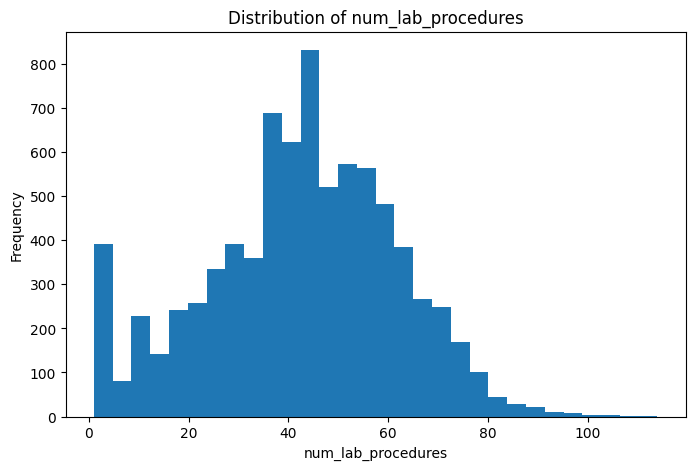

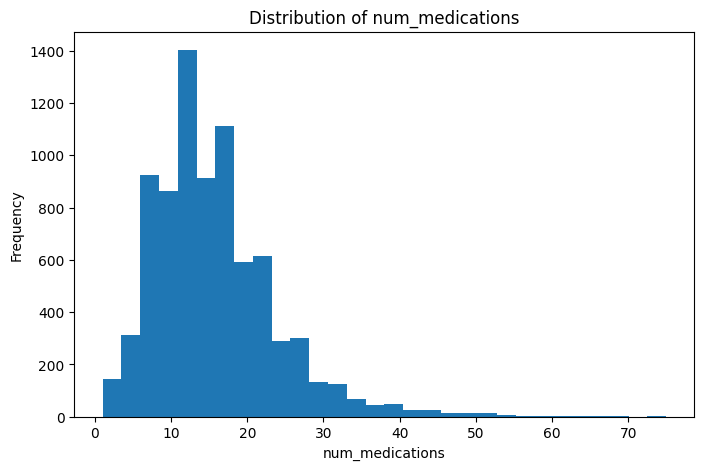

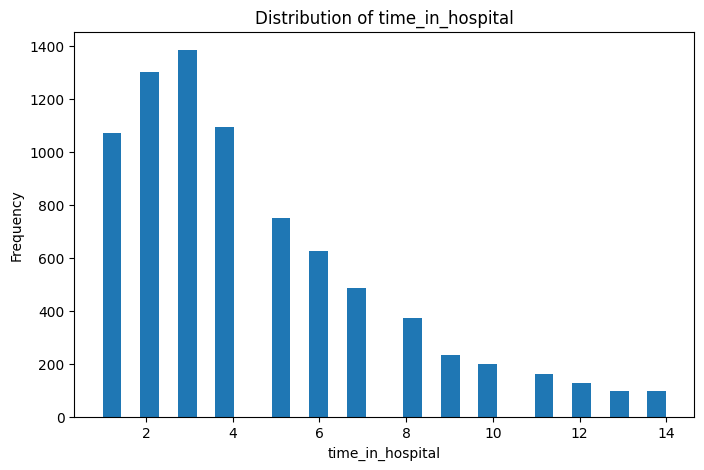

In [303]:
histogram(x_train, "num_lab_procedures")
histogram(x_train, "num_medications")
histogram(x_train, "time_in_hospital")

In [304]:
#Box Plot
def box_plot(data, column):

    plt.figure(figsize=(8, 5))

    plt.boxplot(data[column].dropna())

    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)
    plt.ylabel("Value")

    plt.show()

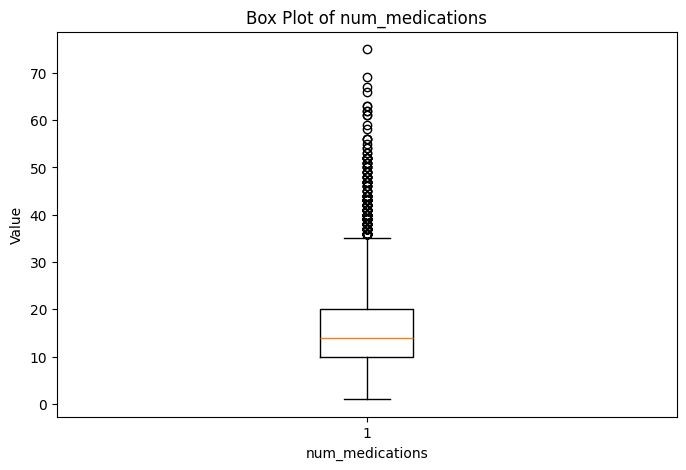

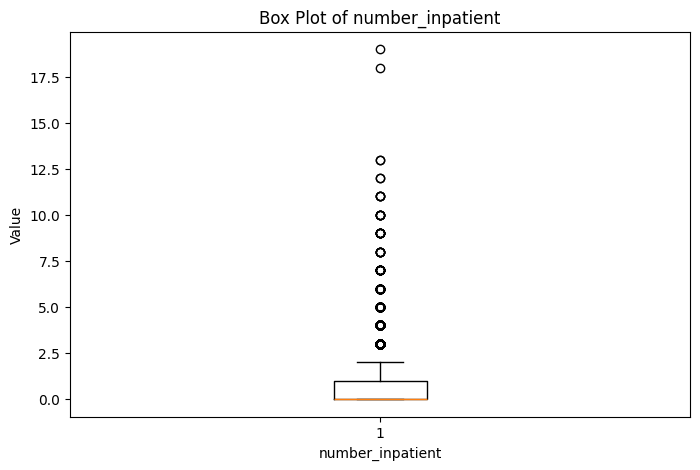

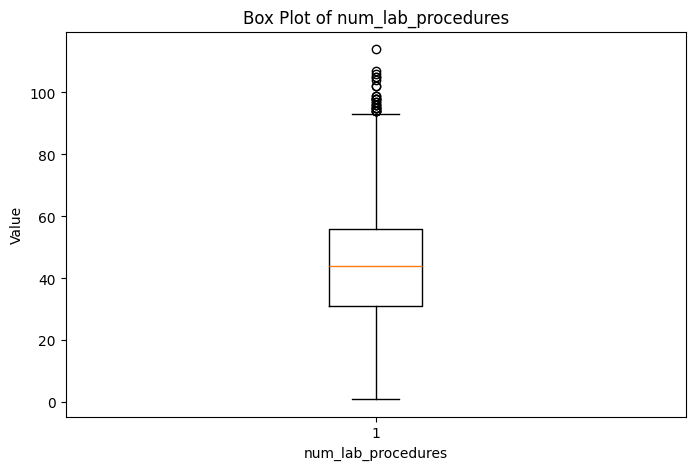

In [305]:
box_plot(x_train, "num_medications")
box_plot(x_train, "number_inpatient")
box_plot(x_train, "num_lab_procedures")

In [306]:
#Bar Chart
def bar_chart(data, column):

    counts = data[column].value_counts()

    plt.figure(figsize=(8, 5))

    plt.bar(counts.index.astype(str), counts.values)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Patients")

    plt.xticks(rotation=45)
    plt.show()

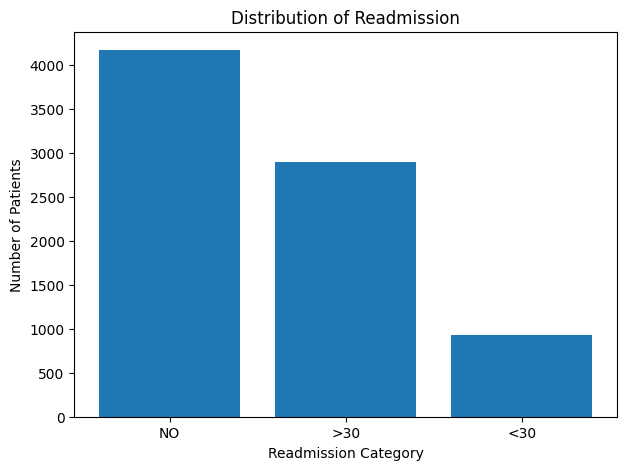

In [307]:
plt.figure(figsize=(7, 5))

counts = y_train.value_counts()

plt.bar(counts.index.astype(str), counts.values)

plt.title("Distribution of Readmission")
plt.xlabel("Readmission Category")
plt.ylabel("Number of Patients")

plt.show()

In [308]:
#Scatter Plot
def scatter_plot(data, column_x, column_y):

    plt.figure(figsize=(8, 5))

    plt.scatter(
        data[column_x],
        data[column_y],
        alpha=0.5
    )

    plt.title(f"{column_x} vs {column_y}")
    plt.xlabel(column_x)
    plt.ylabel(column_y)

    plt.show()

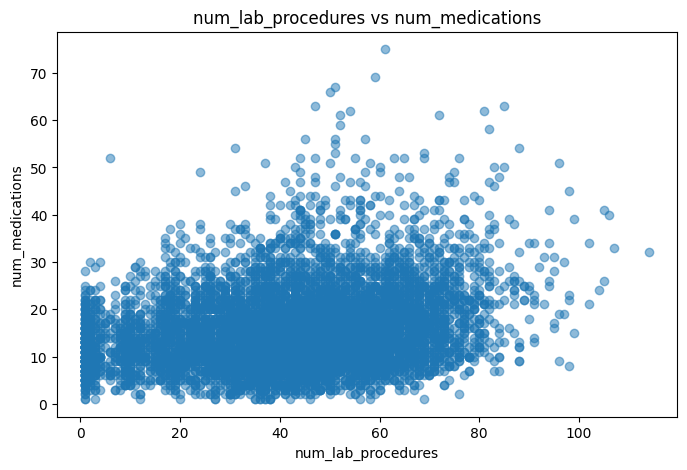

In [309]:
scatter_plot(
    x_train,
    "num_lab_procedures",
    "num_medications"
)

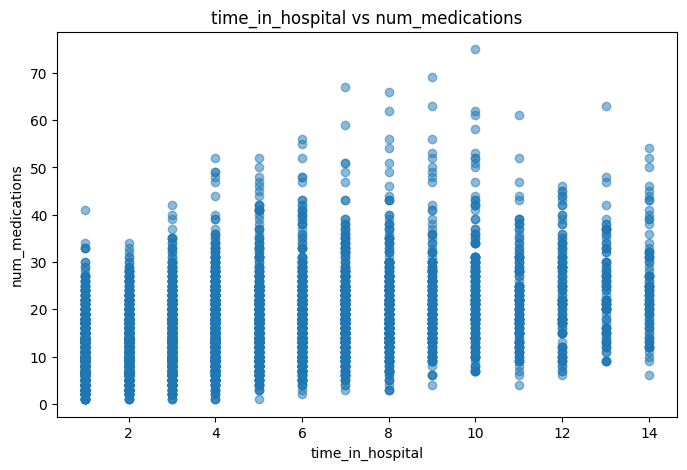

In [310]:
scatter_plot(
    x_train,
    "time_in_hospital",
    "num_medications"
)

In [311]:
#Heatmap
heatmap_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

In [312]:
def correlation_heatmap(data, columns):

    correlation_matrix = data[columns].corr()

    plt.figure(figsize=(12, 8))

    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f"
    )

    plt.title("Correlation Heatmap of Numerical Features")
    plt.xlabel("Features")
    plt.ylabel("Features")

    plt.show()

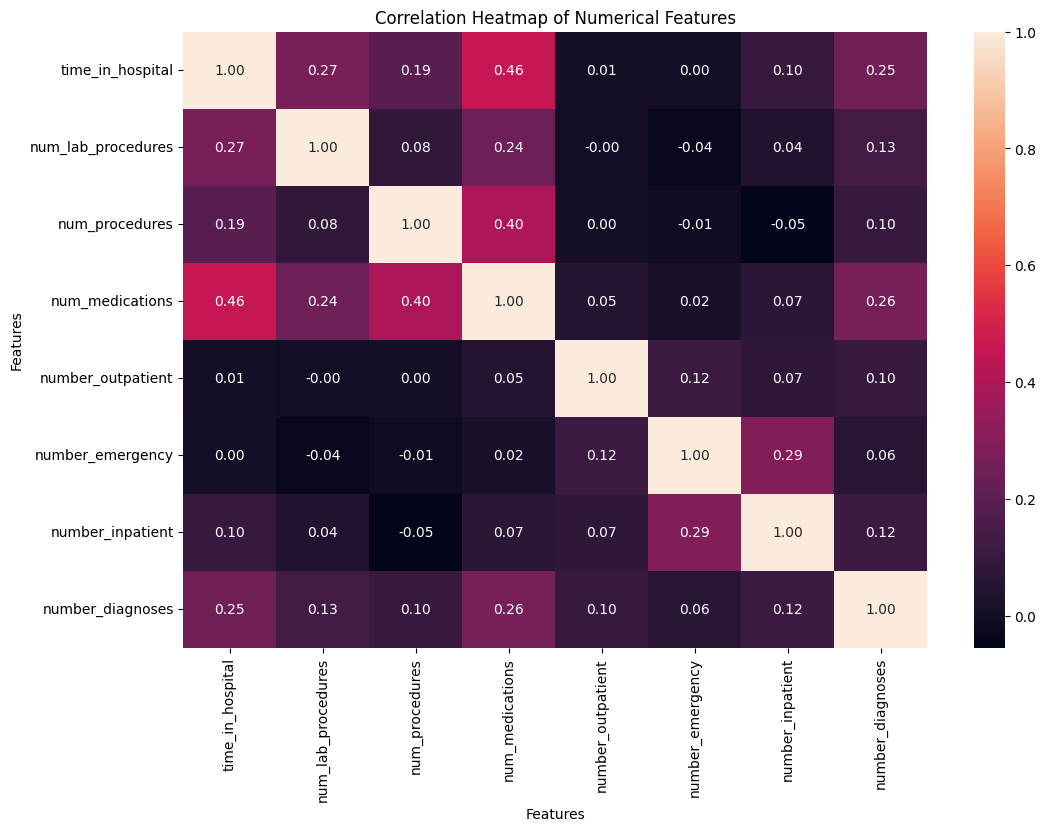

In [313]:
correlation_heatmap(
    x_train,
    heatmap_features
)